## Dependencies

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

## Performance coefficients

In [2]:
def accuracy_coef(pred, groundtruth, smooth=1e-5):
    """Calculate accuracy based on TP, TN, FP, FN"""
    pred = (pred > 0.5).float()
    groundtruth = (groundtruth > 0.5).float()
    
    # Calculate TP, TN, FP, FN
    TP = torch.sum(pred * groundtruth)
    TN = torch.sum((1 - pred) * (1 - groundtruth))
    FP = torch.sum(pred * (1 - groundtruth))
    FN = torch.sum((1 - pred) * groundtruth)
    
    # Calculate accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN + smooth)
    return accuracy

def dice_coef(pred, groundtruth, smooth=1e-5):
    """Calculate Dice coefficient between predicted and groundtruth masks"""
    intersection = torch.sum(pred * groundtruth)
    union = torch.sum(pred) + torch.sum(groundtruth)
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def dice_loss(pred, groundtruth):
    """Calculate Dice loss"""
    return 1 - dice_coef(pred, groundtruth)

def iou_coef(pred, groundtruth, smooth=1e-5):
    """Calculate IoU (Intersection over Union) coefficient"""
    intersection = torch.sum(pred * groundtruth)
    union = torch.sum(pred) + torch.sum(groundtruth) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

def bce_dice_loss(pred, groundtruth, alpha=0.5):
    """Combined BCE and Dice loss"""
    bce = nn.BCELoss()(pred, groundtruth)
    dice = dice_loss(pred, groundtruth)
    return alpha * bce + (1 - alpha) * dice

## Parameters

In [3]:
# Global configuration parameters
TEST_SPLIT = 0.2          # Validation split ratio
VAL_SPLIT = 0.875         # 10/80 after test split
RANDOM_SEED = 42          # Random seed for reproducibility
IMAGE_SIZE = 256          # Input image size
BATCH_SIZE = 16           # Batch size for training
LEARNING_RATE = 0.001     # Initial learning rate
WEIGHT_DECAY = 1e-6       # Weight decay for regularization
NUM_EPOCHS = 50           # Number of training epochs

# Set device (GPU/CPU)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Data Loading and Dataset Class:

In [4]:
def load_segmentation_data(img_paths, mask_paths, shape=256):
    """Load and preprocess image and mask data"""
    images = []
    masks = []
    classes = []
    
    file_pairs_arr = []
    # Get image names
    for img_path in img_paths:
        img_names = os.listdir(img_path)
        base_names = list(set(name.split(')')[0] for name in img_names))
        file_pairs = [(f"{base}).png", f"{base})_mask.png") for base in base_names]
        file_pairs_arr.append(file_pairs)
    
    # Define transformations
    transform = transforms.Compose([
        transforms.Resize((shape, shape)),
        transforms.ToTensor()
    ])
    
    for i,file_pairs in enumerate(file_pairs_arr):
        for img_name, mask_name in file_pairs:
            img = Image.open(os.path.join(img_paths[i], img_name)).convert('L')
            mask = Image.open(os.path.join(mask_paths[i], mask_name)).convert('L')
            
            img_tensor = transform(img)
            mask_tensor = transform(mask)
            
            images.append(img_tensor)
            masks.append(mask_tensor)
            classes.append(torch.tensor(i))

    return torch.stack(images), torch.stack(masks), torch.stack(classes)

class CustomDataset(Dataset):
    """Custom dataset for breast cancer segmentation"""
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]

## Basic Model Building Blocks:

In [5]:
class Conv2dBlock(nn.Module):
    """Basic convolutional block for UNet"""
    def __init__(self, in_channels, out_channels, kernel_size=3, do_batch_norm=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding='same')
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding='same')
        self.batch_norm1 = nn.BatchNorm2d(out_channels) if do_batch_norm else nn.Identity()
        self.batch_norm2 = nn.BatchNorm2d(out_channels) if do_batch_norm else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.relu(x)
        return x

## UNet Model Architecture:

In [6]:
class UNet(nn.Module):
    """UNet architecture for image segmentation"""
    def __init__(self, in_channels=1, num_filters=16, dropout=0.1, do_batch_norm=True):
        super().__init__()
        
        # Encoder
        self.conv1 = Conv2dBlock(in_channels, num_filters, do_batch_norm=do_batch_norm)
        self.conv2 = Conv2dBlock(num_filters, num_filters*2, do_batch_norm=do_batch_norm)
        self.conv3 = Conv2dBlock(num_filters*2, num_filters*4, do_batch_norm=do_batch_norm)
        self.conv4 = Conv2dBlock(num_filters*4, num_filters*8, do_batch_norm=do_batch_norm)
        
        # Bridge
        self.bridge = Conv2dBlock(num_filters*8, num_filters*16, do_batch_norm=do_batch_norm)
        
        # Decoder
        self.up_conv4 = nn.ConvTranspose2d(num_filters*16, num_filters*8, kernel_size=2, stride=2)
        self.conv6 = Conv2dBlock(num_filters*16, num_filters*8, do_batch_norm=do_batch_norm)
        
        self.up_conv3 = nn.ConvTranspose2d(num_filters*8, num_filters*4, kernel_size=2, stride=2)
        self.conv7 = Conv2dBlock(num_filters*8, num_filters*4, do_batch_norm=do_batch_norm)
        
        self.up_conv2 = nn.ConvTranspose2d(num_filters*4, num_filters*2, kernel_size=2, stride=2)
        self.conv8 = Conv2dBlock(num_filters*4, num_filters*2, do_batch_norm=do_batch_norm)
        
        self.up_conv1 = nn.ConvTranspose2d(num_filters*2, num_filters, kernel_size=2, stride=2)
        self.conv9 = Conv2dBlock(num_filters*2, num_filters, do_batch_norm=do_batch_norm)
        
        self.output = nn.Conv2d(num_filters, 1, kernel_size=1)
        
        self.maxpool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder path
        c1 = self.conv1(x)
        p1 = self.dropout(self.maxpool(c1))
        
        c2 = self.conv2(p1)
        p2 = self.dropout(self.maxpool(c2))
        
        c3 = self.conv3(p2)
        p3 = self.dropout(self.maxpool(c3))
        
        c4 = self.conv4(p3)
        p4 = self.dropout(self.maxpool(c4))
        
        # Bridge
        bridge = self.bridge(p4)
        
        # Decoder path
        up4 = self.up_conv4(bridge)
        merge4 = torch.cat([up4, c4], dim=1)
        c6 = self.conv6(self.dropout(merge4))
        
        up3 = self.up_conv3(c6)
        merge3 = torch.cat([up3, c3], dim=1)
        c7 = self.conv7(self.dropout(merge3))
        
        up2 = self.up_conv2(c7)
        merge2 = torch.cat([up2, c2], dim=1)
        c8 = self.conv8(self.dropout(merge2))
        
        up1 = self.up_conv1(c8)
        merge1 = torch.cat([up1, c1], dim=1)
        c9 = self.conv9(self.dropout(merge1))
        
        output = self.sigmoid(self.output(c9))
        return output

## Training Class Implementation:

In [7]:
class Trainer:
    """Training class for UNet model"""
    def __init__(self, model, num_epochs, optimizer, device):
        self.model = model
        self.num_epochs = num_epochs
        self.optimizer = optimizer
        self.device = device
        self.criterion = bce_dice_loss
        
        # Metrics tracking
        self.train_losses = []
        self.val_losses = []
        self.train_dices = []
        self.val_dices = []
        self.train_accs = []
        self.val_accs = []
        self.train_ious = []
        self.val_ious = []
        
        # Best model tracking
        self.best_model = None
        self.best_dice = 0.0
        self.best_epoch = 0
        self.best_model_path = 'best_model.pth'

    def train(self, train_loader, val_loader):
        for epoch in range(self.num_epochs):
            # Training phase
            self.model.train()
            train_loss = 0
            train_dice = 0
            train_acc = 0
            train_iou = 0
            
            for images, masks in train_loader:
                images, masks = images.to(self.device), masks.to(self.device)
                
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                
                loss.backward()
                self.optimizer.step()
                
                train_loss += loss.item()
                train_dice += dice_coef(outputs, masks).item()
                train_acc += accuracy_coef(outputs, masks).item()
                train_iou += iou_coef(outputs, masks).item()
            
            avg_train_loss = train_loss / len(train_loader)
            avg_train_dice = train_dice / len(train_loader)
            avg_train_acc = train_acc / len(train_loader)
            avg_train_iou = train_iou / len(train_loader)
            
            # Validation phase
            self.model.eval()
            val_loss = 0
            val_dice = 0
            val_acc = 0
            val_iou = 0
            
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(self.device), masks.to(self.device)
                    outputs = self.model(images)
                    val_loss += self.criterion(outputs, masks).item()
                    val_dice += dice_coef(outputs, masks).item()
                    val_acc += accuracy_coef(outputs, masks).item()
                    val_iou += iou_coef(outputs, masks).item()
            
            avg_val_loss = val_loss / len(val_loader)
            avg_val_dice = val_dice / len(val_loader)
            avg_val_acc = val_acc / len(val_loader)
            avg_val_iou = val_iou / len(val_loader)
            
            # Save metrics
            self.train_losses.append(avg_train_loss)
            self.val_losses.append(avg_val_loss)
            self.train_dices.append(avg_train_dice)
            self.val_dices.append(avg_val_dice)
            self.train_accs.append(avg_train_acc)
            self.val_accs.append(avg_val_acc)
            self.train_ious.append(avg_train_iou)
            self.val_ious.append(avg_val_iou)

            
            # Save the best model
            if avg_val_dice > self.best_dice:
                self.best_dice = avg_val_dice
                self.best_epoch = epoch
                self.best_model = self.model.state_dict()
                torch.save(self.best_model, self.best_model_path)
                
            print(f'Epoch [{epoch+1}/{self.num_epochs}]')
            print(f'Train Loss: {avg_train_loss:.4f}, Train Dice: {avg_train_dice:.4f}, Train Acc: {avg_train_acc:.4f}, Train IoU: {avg_train_iou:.4f}')
            print(f'Val Loss: {avg_val_loss:.4f}, Val Dice: {avg_val_dice:.4f}, Val Acc: {avg_val_acc:.4f}, Val IoU: {avg_val_iou:.4f}')

## Training Process Visualization:

In [8]:
def plot_training_history(trainer):
    """Plot training and validation metrics"""
    epochs = range(1, len(trainer.train_losses) + 1)
    
    plt.figure(figsize=(20, 5))
    
    # Plot Accuracy
    plt.subplot(1, 4, 1)
    plt.plot(epochs, trainer.train_accs, 'b-', label='Training Accuracy')
    plt.plot(epochs, trainer.val_accs, 'r-', label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    # Plot Loss
    plt.subplot(1, 4, 2)
    plt.plot(epochs, trainer.train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, trainer.val_losses, 'r-', label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot Dice Coefficient
    plt.subplot(1, 4, 3)
    plt.plot(epochs, trainer.train_dices, 'b-', label='Training Dice')
    plt.plot(epochs, trainer.val_dices, 'r-', label='Validation Dice')
    plt.title('Dice Coefficient')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.legend()
    plt.grid(True)
    
    # Plot IoU
    plt.subplot(1, 4, 4)
    plt.plot(epochs, trainer.train_ious, 'b-', label='Training IoU')
    plt.plot(epochs, trainer.val_ious, 'r-', label='Validation IoU')
    plt.title('IoU Coefficient')
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

## Results Visualization:

In [9]:
def evaluation(model, test_loader, device):
    # predicted_masks = []
    # original_masks = []
    ious = []

    model.eval()
    with torch.no_grad():
        for i, (images, masks) in enumerate(test_loader):
                
            images = images.to(device)
            masks = masks.to(device)
            predictions = model(images)
            
            # Convert tensors to numpy arrays
            image = images[0].cpu().numpy().squeeze()
            mask = masks[0].cpu().numpy().squeeze()
            pred = predictions[0].cpu().numpy().squeeze()

            # predicted_masks.append(pred)
            # original_masks.append(mask)

            this_iou = iou_coef(pred, mask)
            ious.append(this_iou)

    mean_iou = np.mean(np.array(ious))
    # return predicted_masks, original_masks, mean_iou
    return mean_iou

In [10]:
def plot_prediction_results(model, test_loader, device, num_images=3):
    """Display prediction results with original image, predicted mask, and true mask"""
    model.eval()
    with torch.no_grad():
        for i, (images, masks) in enumerate(test_loader):
            if i >= num_images:
                break
                
            images = images.to(device)
            masks = masks.to(device)
            predictions = model(images)
            
            # Convert tensors to numpy arrays
            image = images[0].cpu().numpy().squeeze()
            mask = masks[0].cpu().numpy().squeeze()
            pred = predictions[0].cpu().numpy().squeeze()
            
            # Calculate metrics
            curr_iou = iou_coef(predictions[0], masks[0]).item()
            curr_dice = dice_coef(predictions[0], masks[0]).item()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Original Image
            axes[0].imshow(image, cmap='gray')
            axes[0].set_title('Original Image')
            axes[0].axis('off')
            
            # True Mask
            axes[1].imshow(mask, cmap='gray')
            axes[1].set_title('True Mask')
            axes[1].axis('off')
            
            # Predicted Mask
            axes[2].imshow(pred, cmap='gray')
            axes[2].set_title(f'Predicted Mask\nDice: {curr_dice:.4f}, IoU: {curr_iou:.4f}')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()

## Main Training Process:

Epoch [1/50]
Train Loss: 0.7322, Train Dice: 0.1269, Train Acc: 0.7716, Train IoU: 0.0685
Val Loss: 0.7583, Val Dice: 0.1302, Val Acc: 0.9237, Val IoU: 0.0700
Epoch [2/50]
Train Loss: 0.7034, Train Dice: 0.1399, Train Acc: 0.8539, Train IoU: 0.0758
Val Loss: 0.7370, Val Dice: 0.1296, Val Acc: 0.9237, Val IoU: 0.0696
Epoch [3/50]
Train Loss: 0.6709, Train Dice: 0.1650, Train Acc: 0.8741, Train IoU: 0.0903
Val Loss: 0.7047, Val Dice: 0.1279, Val Acc: 0.9237, Val IoU: 0.0686
Epoch [4/50]
Train Loss: 0.6376, Train Dice: 0.1904, Train Acc: 0.9032, Train IoU: 0.1053
Val Loss: 0.6609, Val Dice: 0.1381, Val Acc: 0.9283, Val IoU: 0.0746
Epoch [5/50]
Train Loss: 0.6183, Train Dice: 0.1975, Train Acc: 0.9084, Train IoU: 0.1099
Val Loss: 0.7579, Val Dice: 0.1517, Val Acc: 0.8331, Val IoU: 0.0825
Epoch [6/50]
Train Loss: 0.5960, Train Dice: 0.2095, Train Acc: 0.9350, Train IoU: 0.1177
Val Loss: 1.2434, Val Dice: 0.1742, Val Acc: 0.7070, Val IoU: 0.0963
Epoch [7/50]
Train Loss: 0.5851, Train Dice: 0

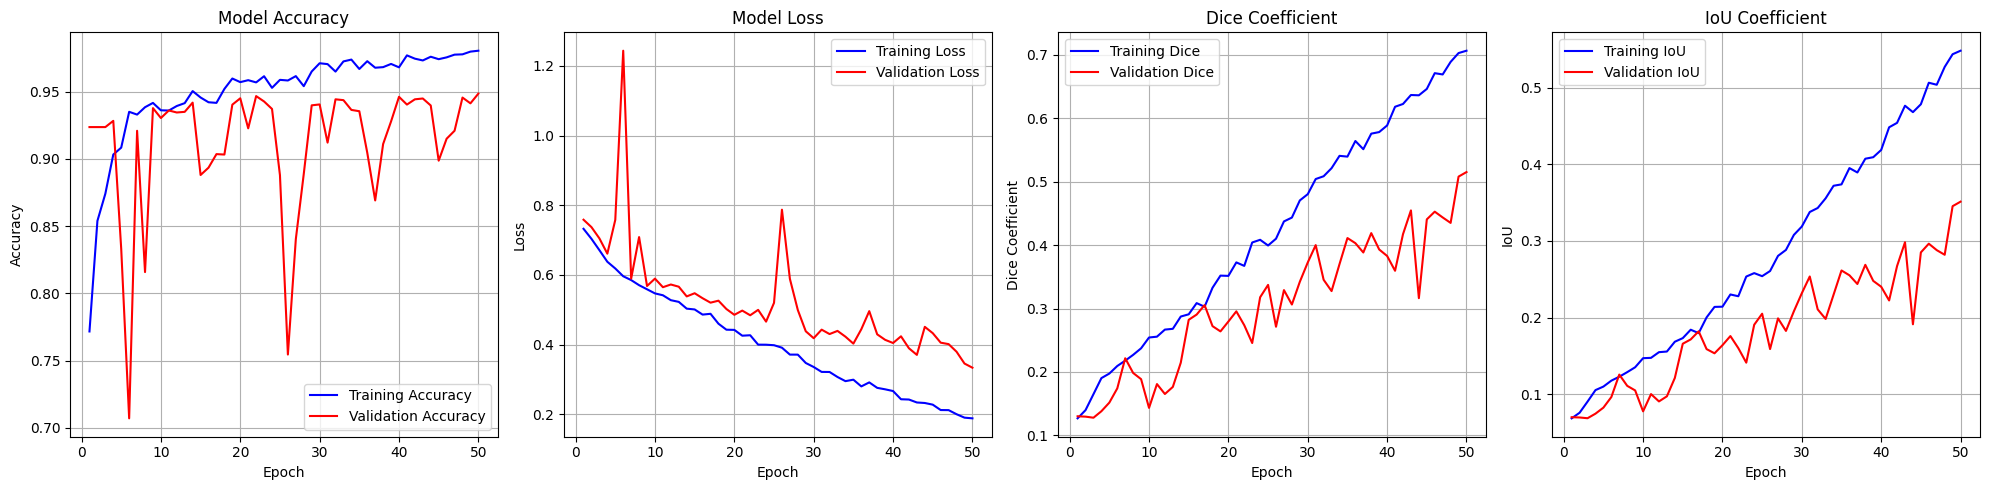

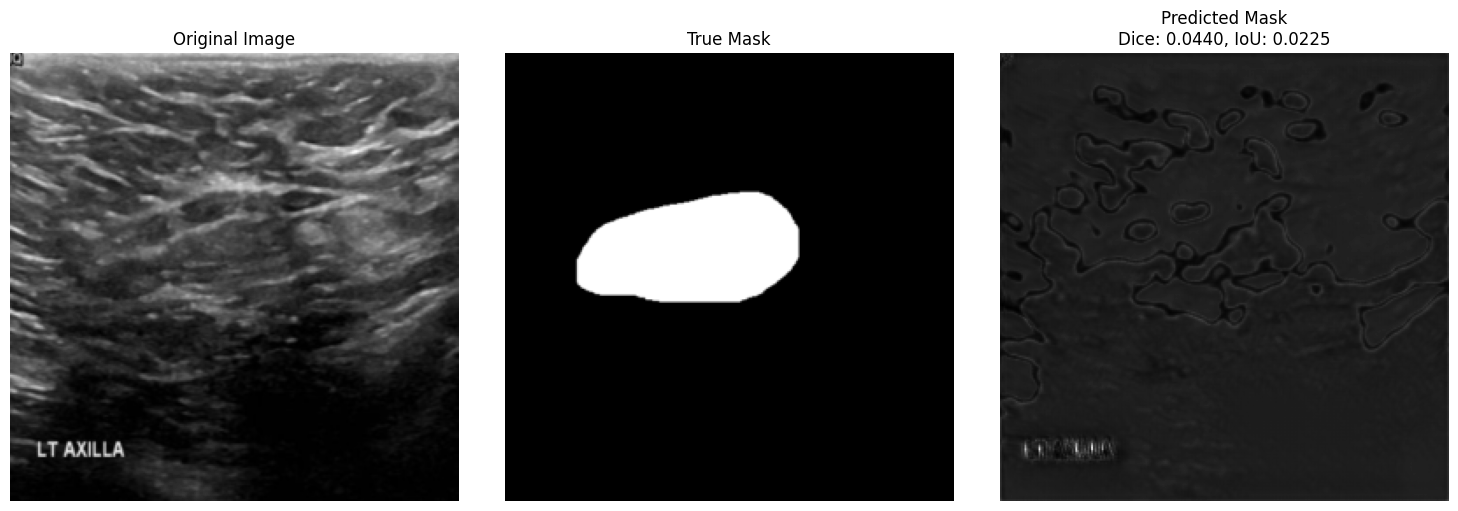

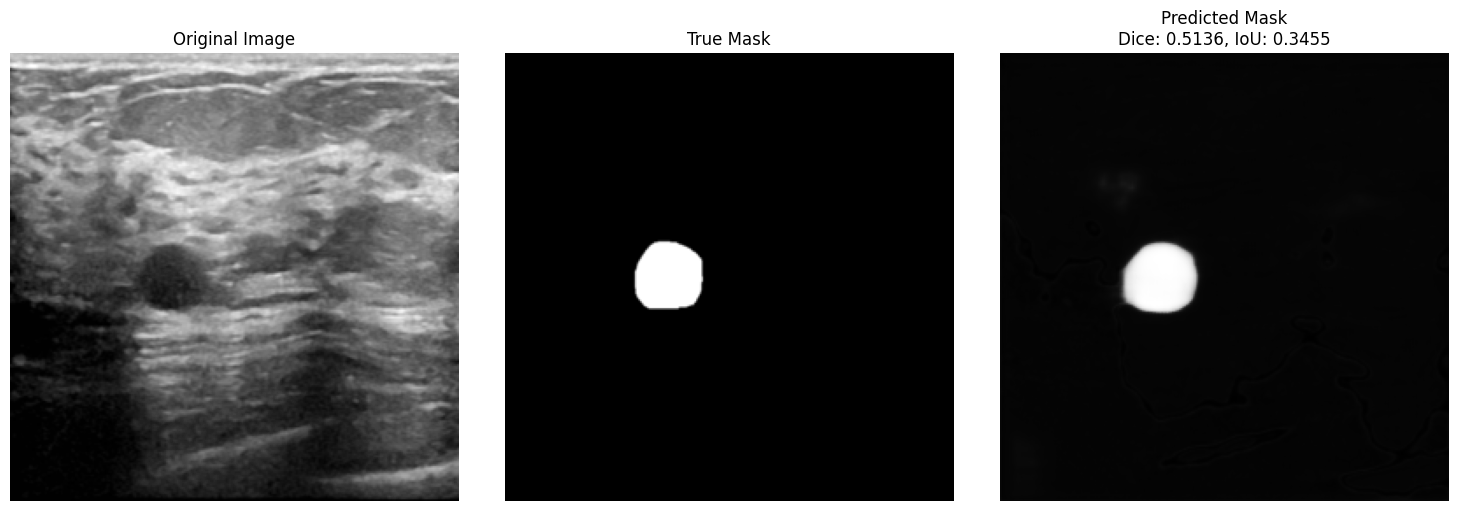

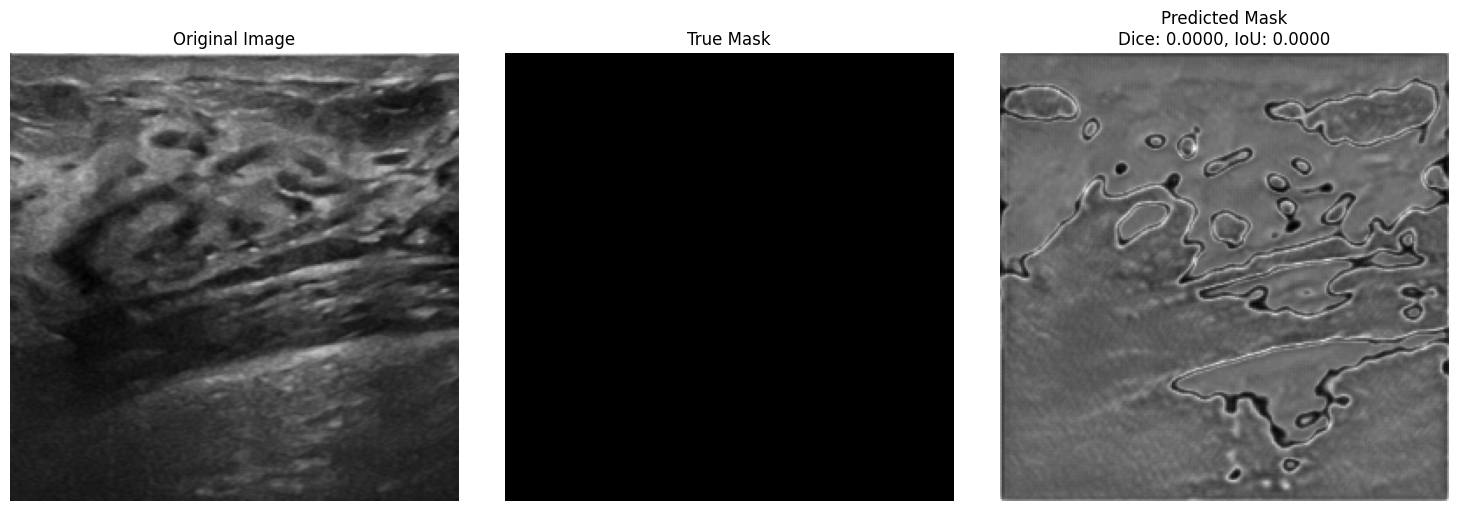

In [11]:
def main():
    # Model Initialization
    model = UNet(in_channels=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    
    # Load and prepare data
    # images, masks = load_segmentation_data('Dataset_BUSI_with_GT/malignant', 'Dataset_BUSI_with_GT/malignant')
    data_path = ['Dataset_BUSI_with_GT/normal', 'Dataset_BUSI_with_GT/benign', 'Dataset_BUSI_with_GT/malignant']
    images, masks, classes = load_segmentation_data(data_path, data_path)

    X_train_large, X_test, y_train_large, y_test, classes_train_large, _ = train_test_split(
        images, masks, classes, 
        test_size=TEST_SPLIT, 
        random_state=RANDOM_SEED, 
        stratify=classes
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_large, y_train_large,
        test_size=VAL_SPLIT, 
        random_state=RANDOM_SEED, 
        stratify=classes_train_large
    )
    
    # Create data loaders
    train_dataset = CustomDataset(X_train, y_train)
    val_dataset = CustomDataset(X_val, y_val)
    test_dataset = CustomDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    
    # Initialize trainer
    trainer = Trainer(model, NUM_EPOCHS, optimizer, device)
    
    # Train model
    trainer.train(train_loader, val_loader)
    
    # Plot training history
    plot_training_history(trainer)
    
    # Plot some predictions
    plot_prediction_results(model, test_loader, device)

if __name__ == "__main__":
    main()